# CIFAR-100 Classification Project Report
**Author**: Adam Szostek  

## 1. Introduction
This report compares the performance of two models on the CIFAR-100 dataset:
1. Custom Convolutional Neural Network (CNN)
2. Fine-tuned ResNet-18

The project aims to evaluate which architecture performs better on this 100-class image classification task.

## 2. Environment Setup

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from src.backbone_dataloader import testloader as resnet_testloader
import sys
import os
from PIL import Image
import json
import pickle
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


sys.path.append('src/')
from conv import Conv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

plt.style.use('ggplot')
%matplotlib inline

100%|██████████| 169001437/169001437 [00:43<00:00, 3926561.07it/s]


Extracting ./data/cifar-100-python.tar.gz to ./data
Files already downloaded and verified
Using device: cuda


## 3. Data Loading

In [2]:
from src.backbone_dataloader import testloader as resnet_testloader
from src.cifar_dataloader import c_testloader as test_loader

# Class names
with open('data/cifar-100-python/meta', 'rb') as f:
    meta = pickle.load(f)
class_names = meta['fine_label_names']

Files already downloaded and verified
Files already downloaded and verified


## 4. Model Architectures

In [3]:
# Custom CNN
custom_model = Conv(num_classes=100).to(device)

# ResNet-18
resnet18 = models.resnet18()
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Sequential(nn.Linear(num_ftrs, 100))
resnet18 = resnet18.to(device)

<div style="text-align: center;">
    <img src="models/Custom_CNN_architecture.drawio.png" alt="Custom CNN Architecture" style="width: 50%;">
    <p style="font-size: 14px; margin-top: 8px;"><b>Custom CNN Architecture</b></p>
</div>

<div style="text-align: center;">
    <img src="models/resnet18_architecture.png" alt="ResNet-18 Architecture" style="width: 50%;">
    <p style="font-size: 14px; margin-top: 8px;"><b>ResNet-18 Architecture</b></p>
</div>

## 5. Model Training History Visualization

<div style="display: flex; justify-content: center; gap: 20px;">
    <div style="text-align: center;">
        <img src="results/conv_training.png" alt="Custom CNN Training History" style="width: 100%;">
        <p style="font-size: 14px; margin-top: 8px;"><b>Custom CNN Training History</b></p>
    </div>
    <div style="text-align: center;">
        <img src="results/resnet_training.png" alt="ResNet-18 Training History" style="width: 100%;">
        <p style="font-size: 14px; margin-top: 8px;"><b>ResNet-18 Training History</b></p>
    </div>
</div>

## 6. Model Evaluation

In [4]:
def evaluate_model(model, model_path, test_loader):
    model.load_state_dict(torch.load(model_path))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

custom_labels, custom_preds = evaluate_model(custom_model, 'models/best_model.pth', test_loader)
resnet_labels, resnet_preds = evaluate_model(resnet18, 'models/resnet18.pth', resnet_testloader)

## 7. Performance Metrics

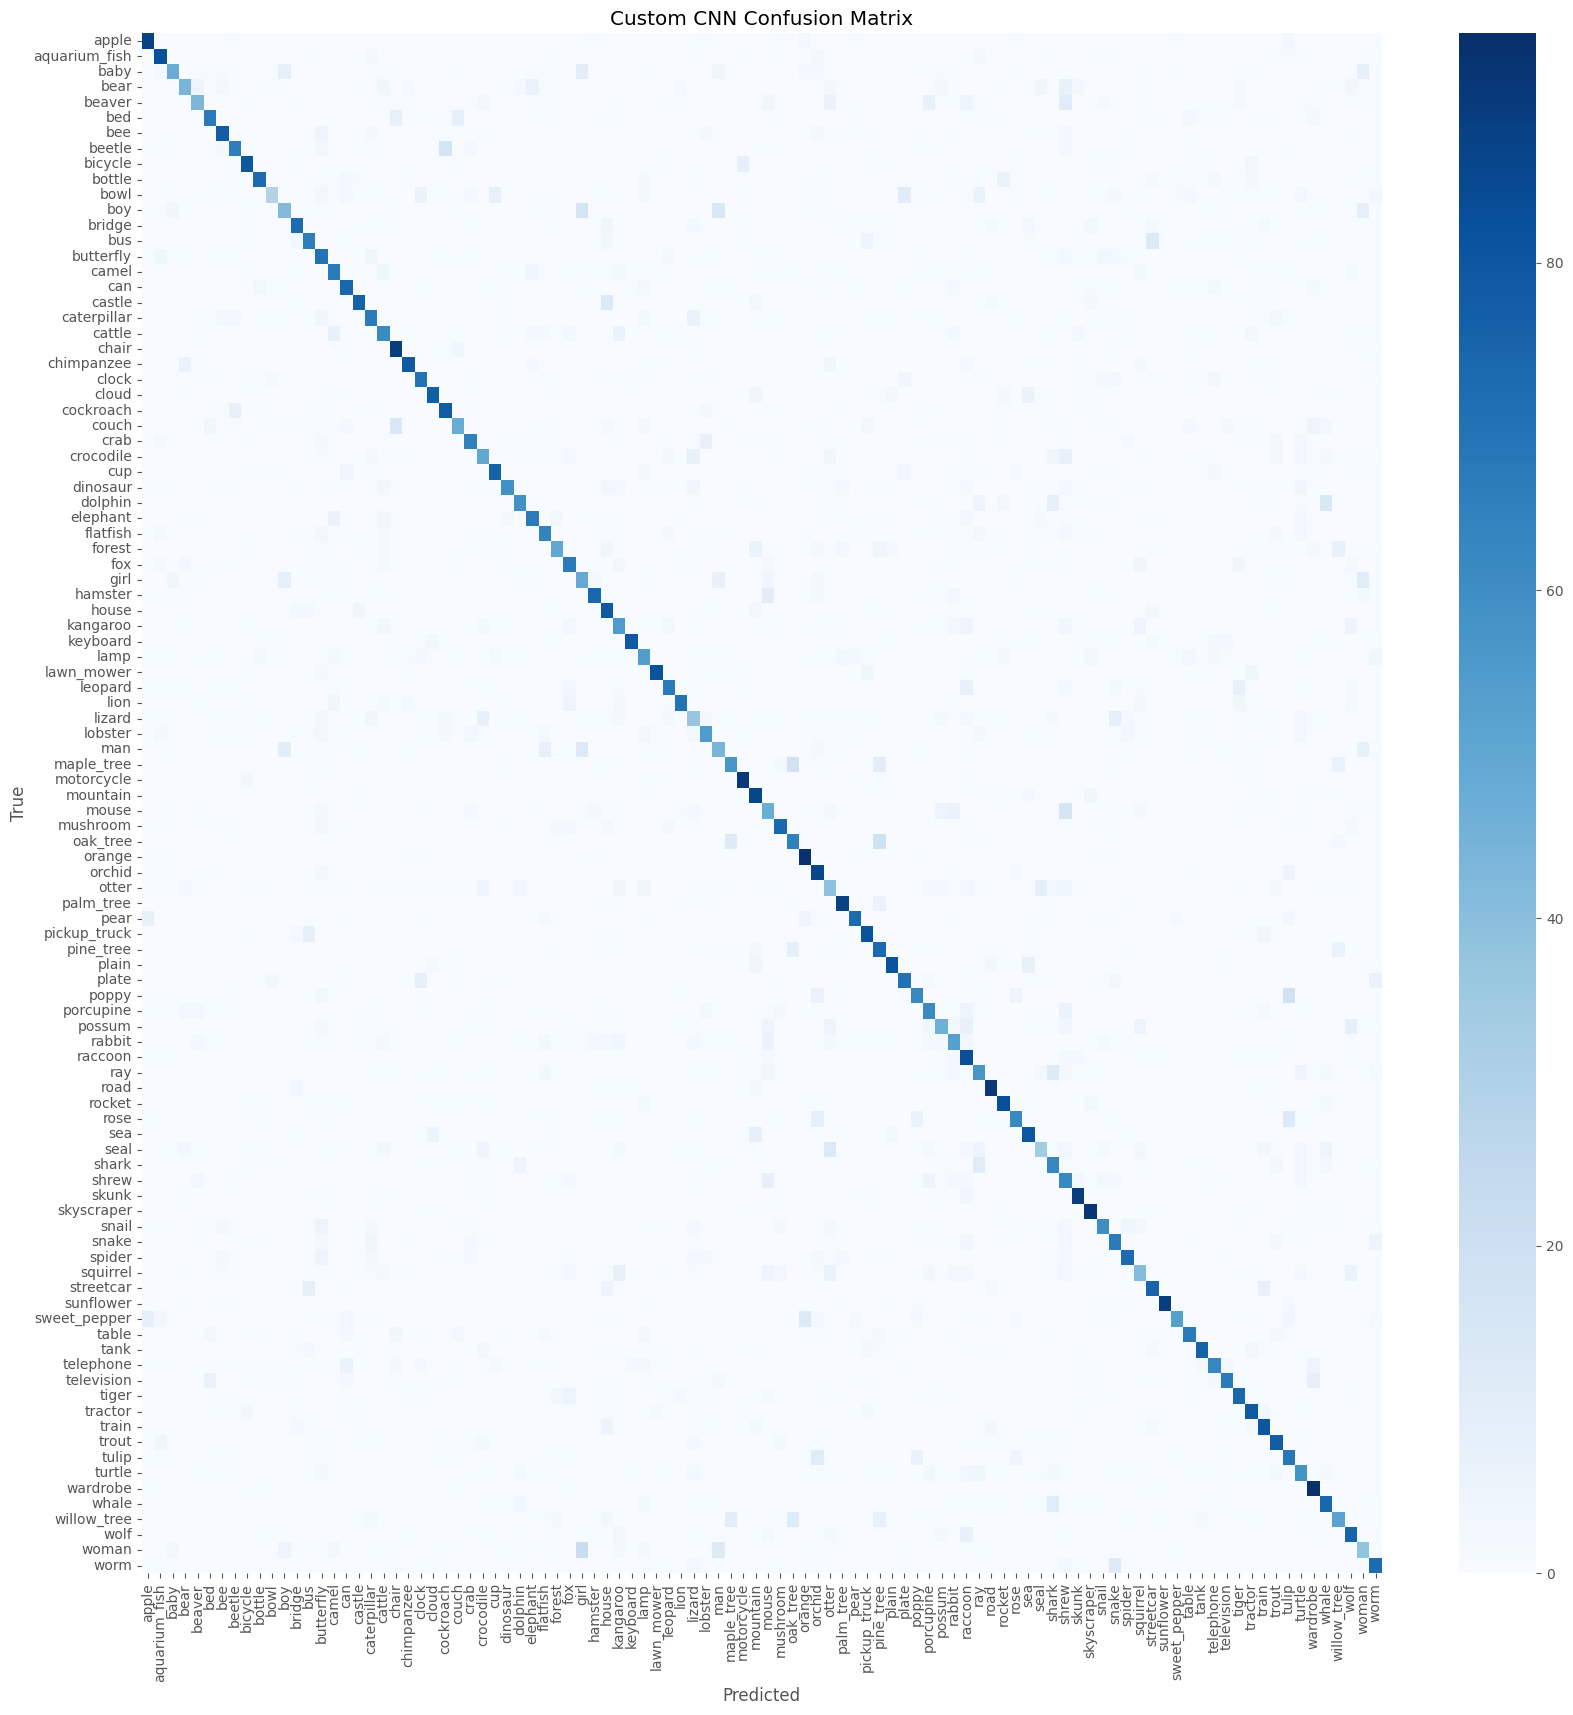

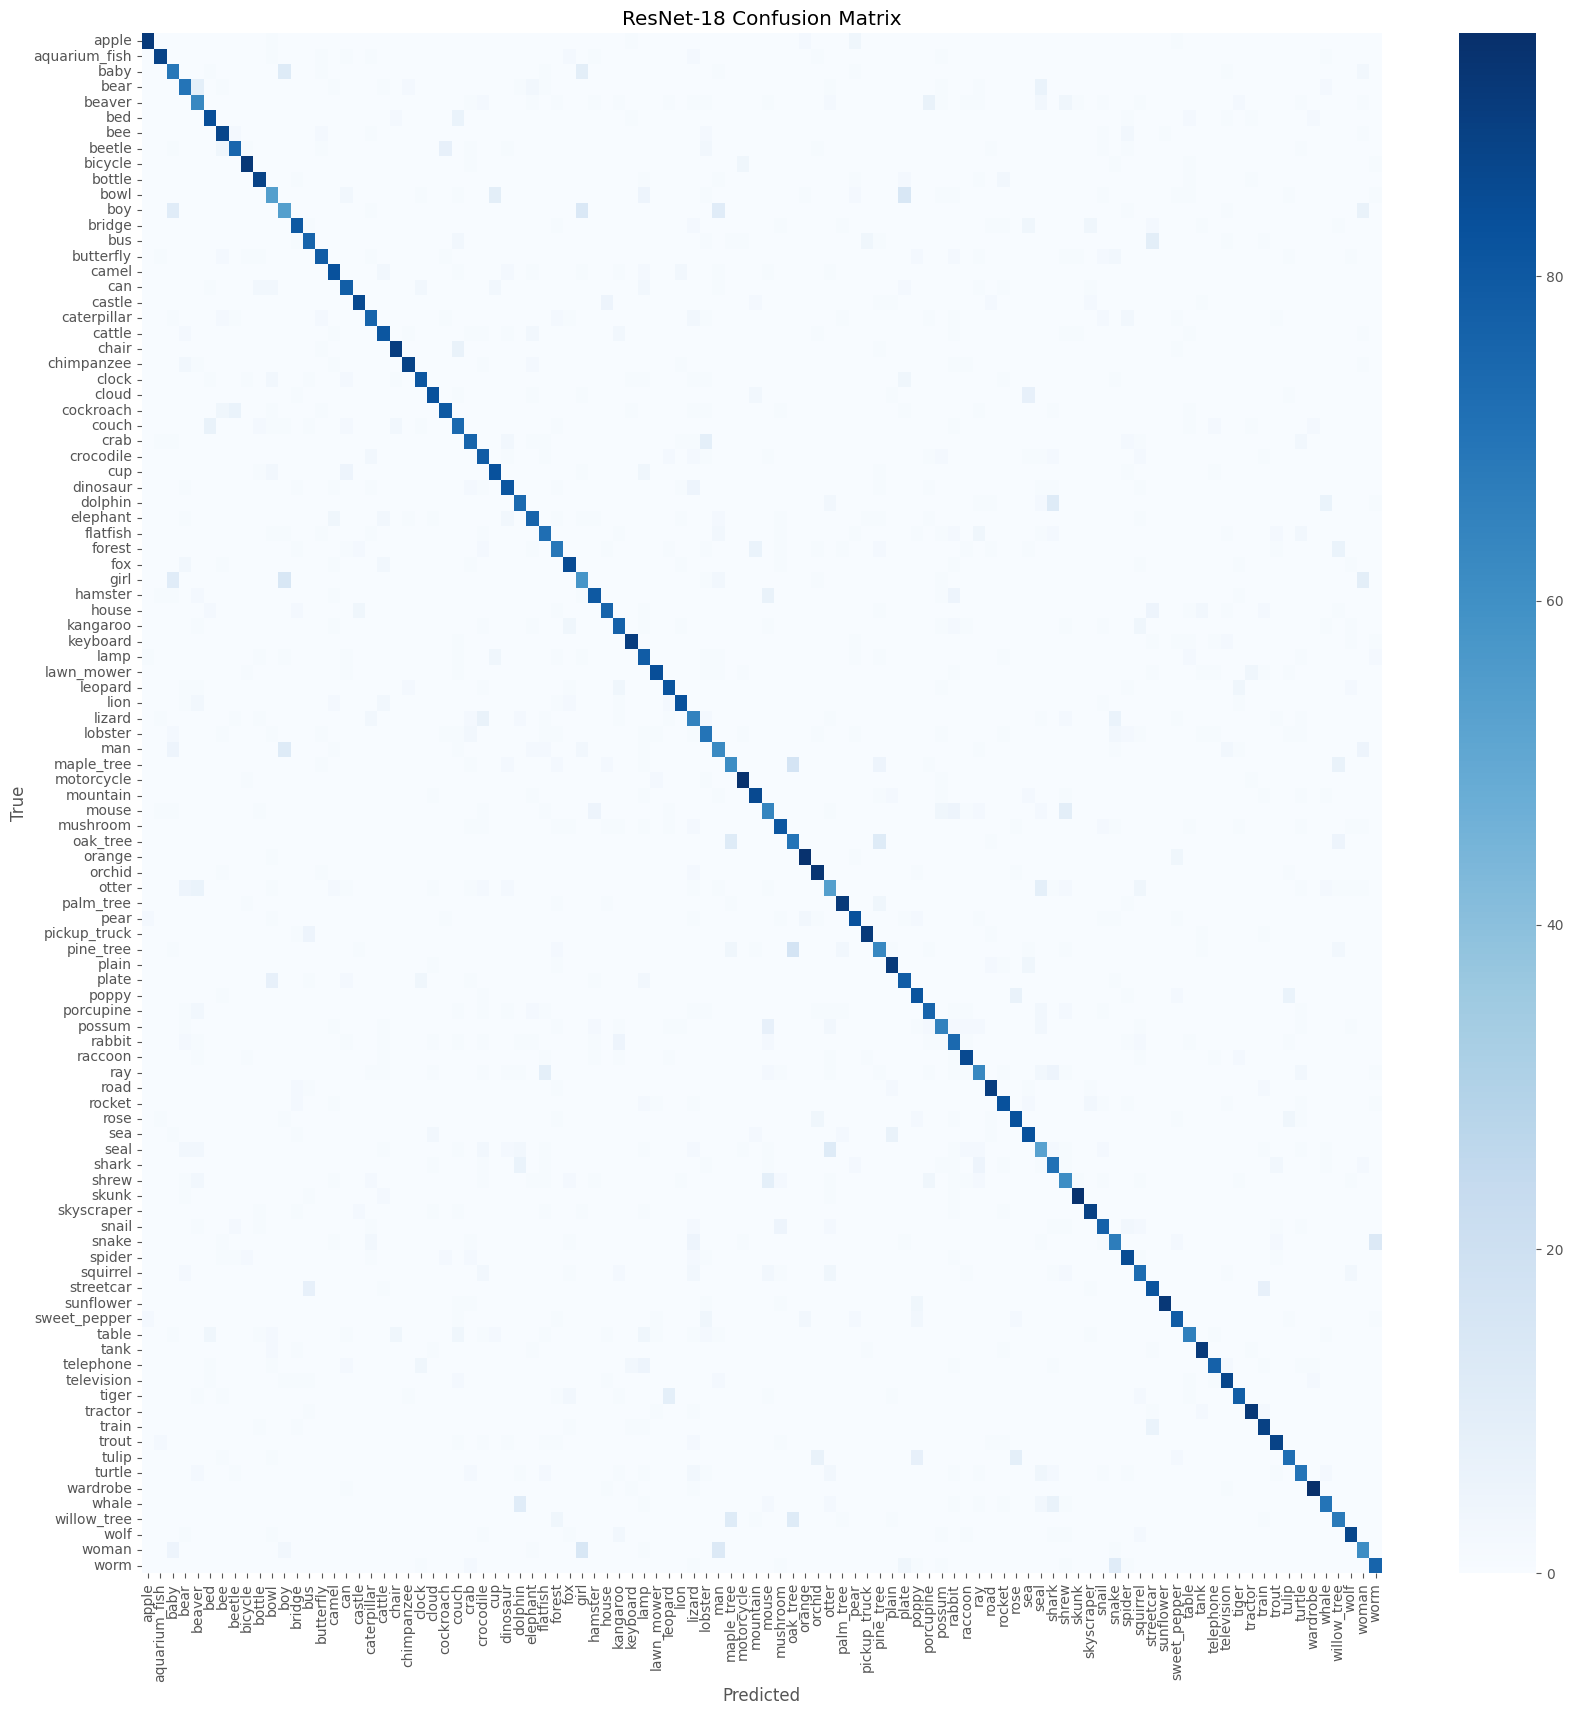

Custom CNN Classification Report:
               precision    recall  f1-score   support

        apple       0.84      0.88      0.86       100
aquarium_fish       0.68      0.82      0.74       100
         baby       0.73      0.48      0.58       100
         bear       0.62      0.44      0.51       100
       beaver       0.63      0.43      0.51       100
          bed       0.77      0.67      0.72       100
          bee       0.73      0.78      0.75       100
       beetle       0.79      0.66      0.72       100
      bicycle       0.79      0.80      0.80       100
       bottle       0.81      0.73      0.77       100
         bowl       0.67      0.29      0.41       100
          boy       0.55      0.42      0.47       100
       bridge       0.73      0.72      0.72       100
          bus       0.71      0.66      0.68       100
    butterfly       0.48      0.70      0.57       100
        camel       0.68      0.67      0.67       100
          can       0.68      

In [5]:
def plot_confusion_matrix(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(20, 20))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Confusion matrices
plot_confusion_matrix(custom_labels, custom_preds, class_names, 'Custom CNN Confusion Matrix')
plot_confusion_matrix(resnet_labels, resnet_preds, class_names, 'ResNet-18 Confusion Matrix')

# Classification reports
print("Custom CNN Classification Report:")
print(classification_report(custom_labels, custom_preds, target_names=class_names, zero_division=0))

print("\nResNet-18 Classification Report:")
print(classification_report(resnet_labels, resnet_preds, target_names=class_names, zero_division=0))

## 8. Accuracy Comparison

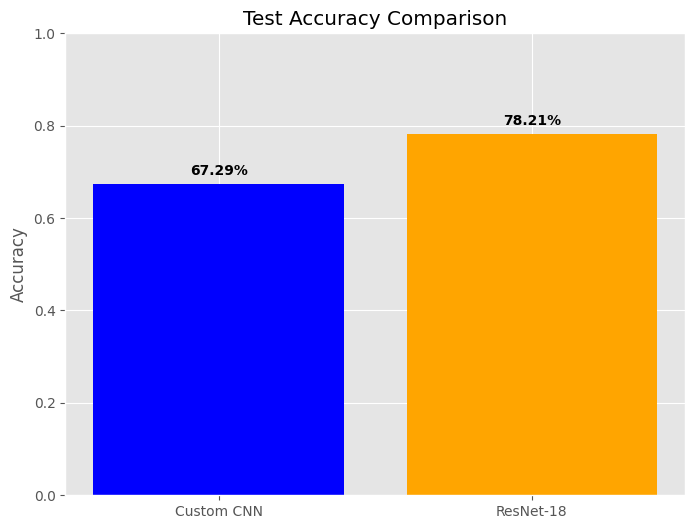

In [6]:
custom_accuracy = np.mean(np.array(custom_labels) == np.array(custom_preds))
resnet_accuracy = np.mean(np.array(resnet_labels) == np.array(resnet_preds))

plt.figure(figsize=(8, 6))
bars = plt.bar(['Custom CNN', 'ResNet-18'],
    [custom_accuracy, resnet_accuracy],
    color=['blue', 'orange'])
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{bar.get_height():.2%}',
        ha='center',
        fontsize=10,
        fontweight='bold')

plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.show()

## 9. Per-Class Accuracy Analysis

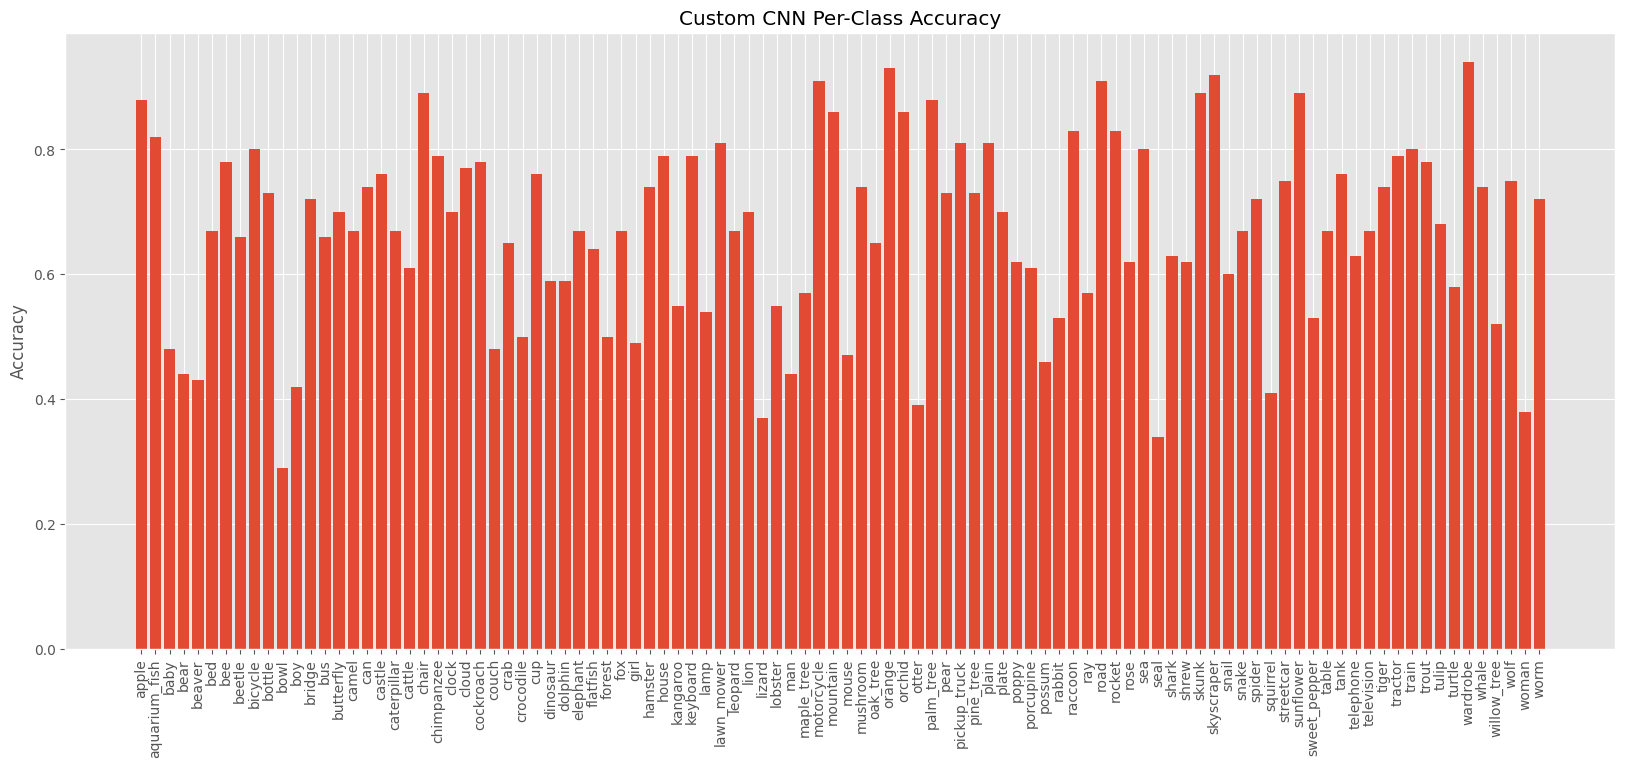

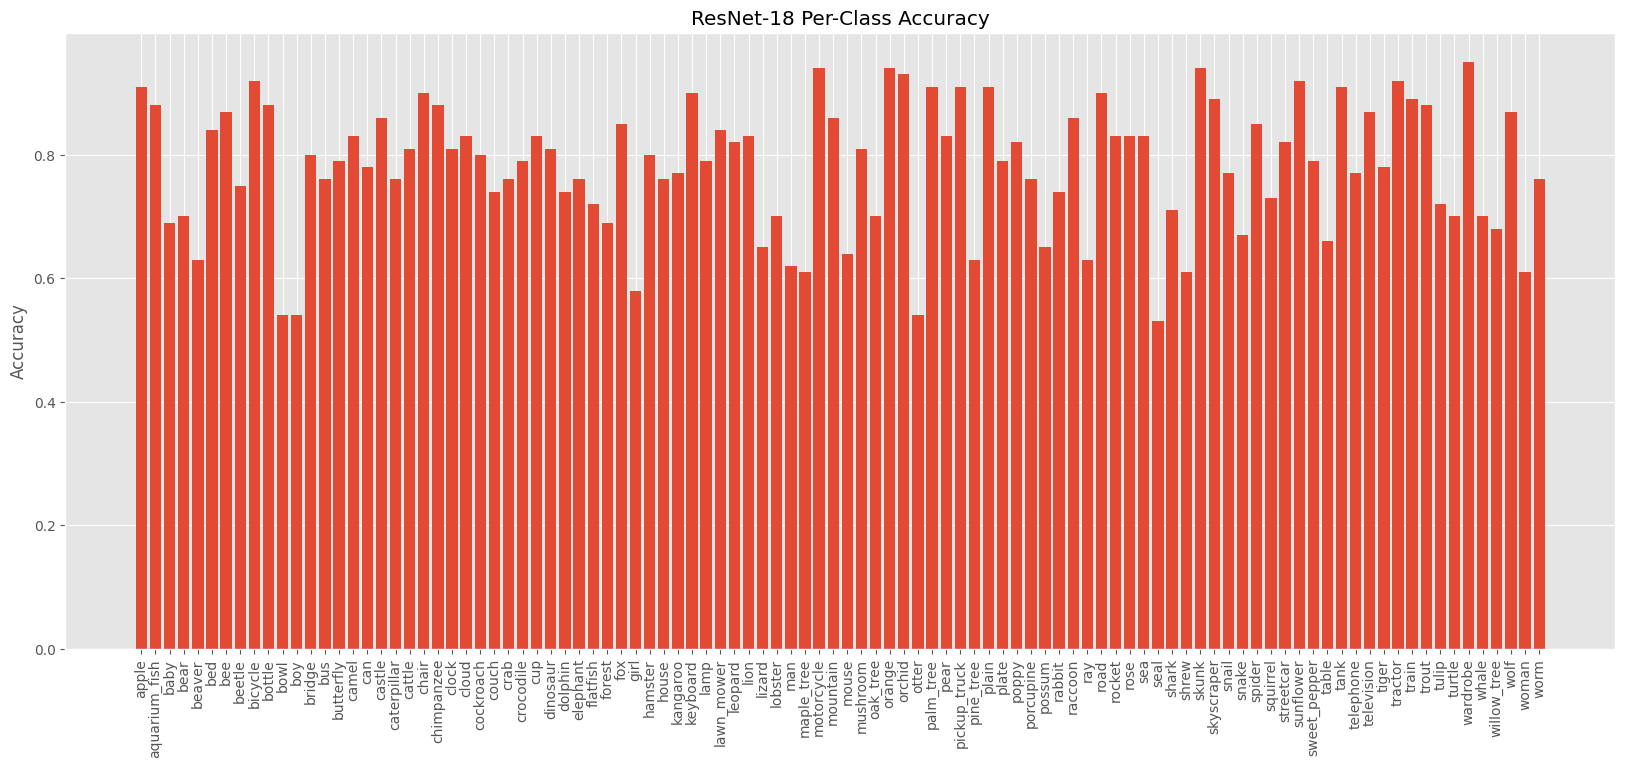

In [7]:
def plot_class_accuracy(labels, preds, class_names, title):
    class_acc = []
    for i in range(100):
        class_mask = np.array(labels) == i
        class_acc.append(np.mean(np.array(preds)[class_mask] == i))

    plt.figure(figsize=(20, 8))
    plt.bar(range(100), class_acc)
    plt.xticks(range(100), class_names, rotation=90)
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.show()

plot_class_accuracy(custom_labels, custom_preds, class_names, 'Custom CNN Per-Class Accuracy')
plot_class_accuracy(resnet_labels, resnet_preds, class_names, 'ResNet-18 Per-Class Accuracy')

## 10. Sample Predictions

Custom CNN Sample Predictions:


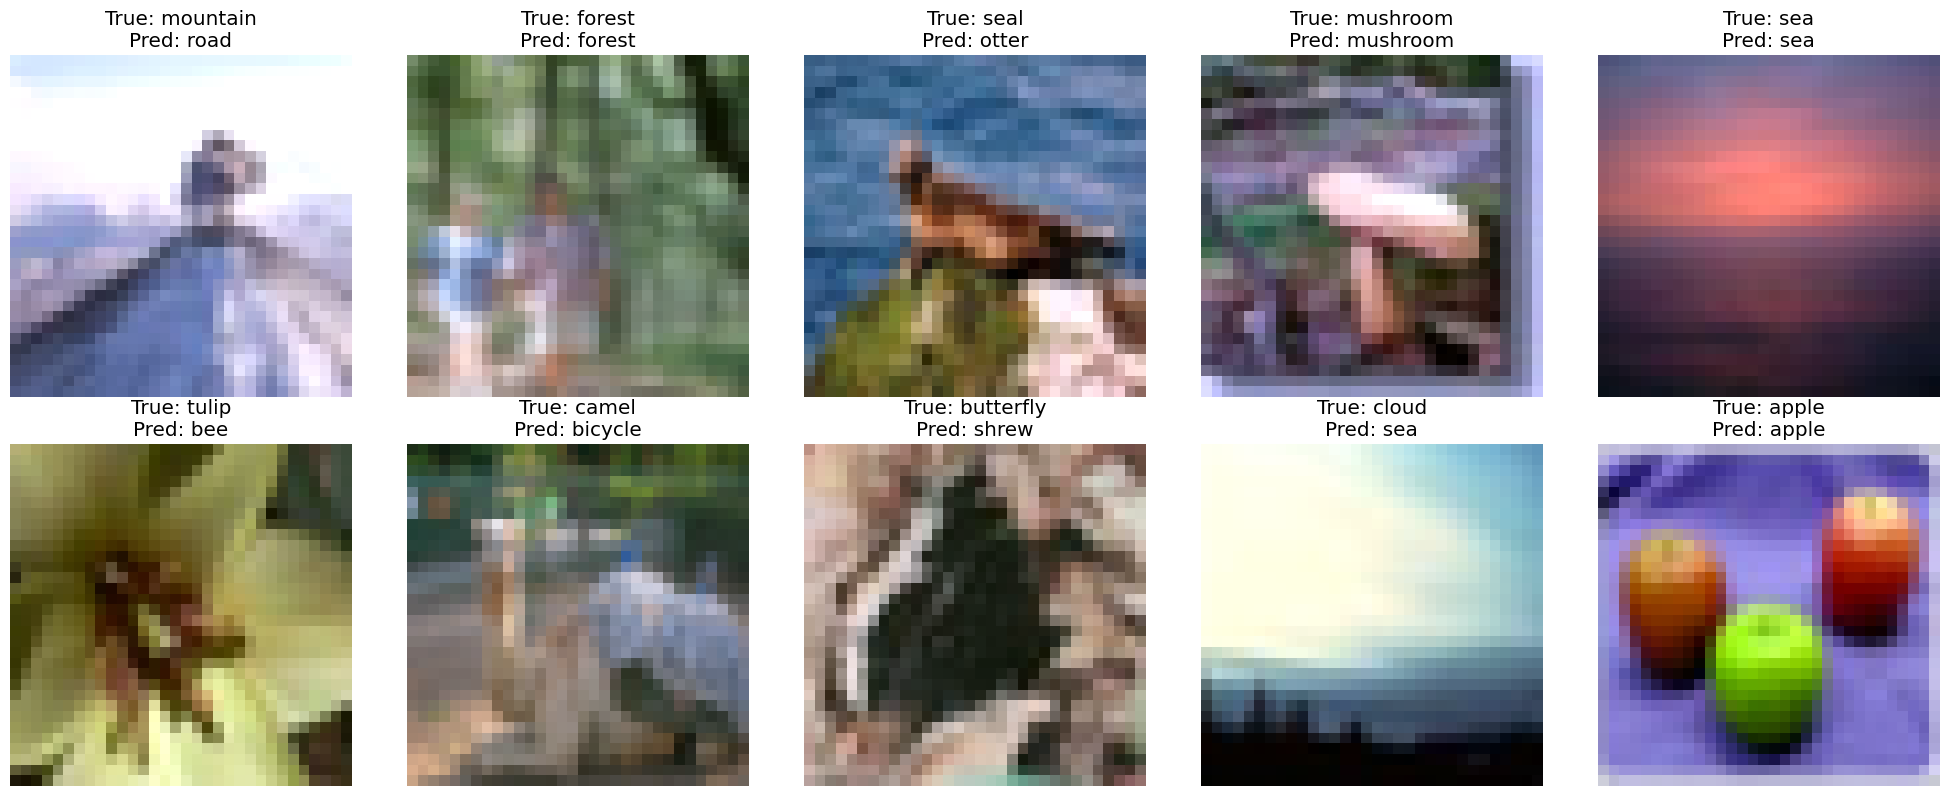


ResNet-18 Sample Predictions:


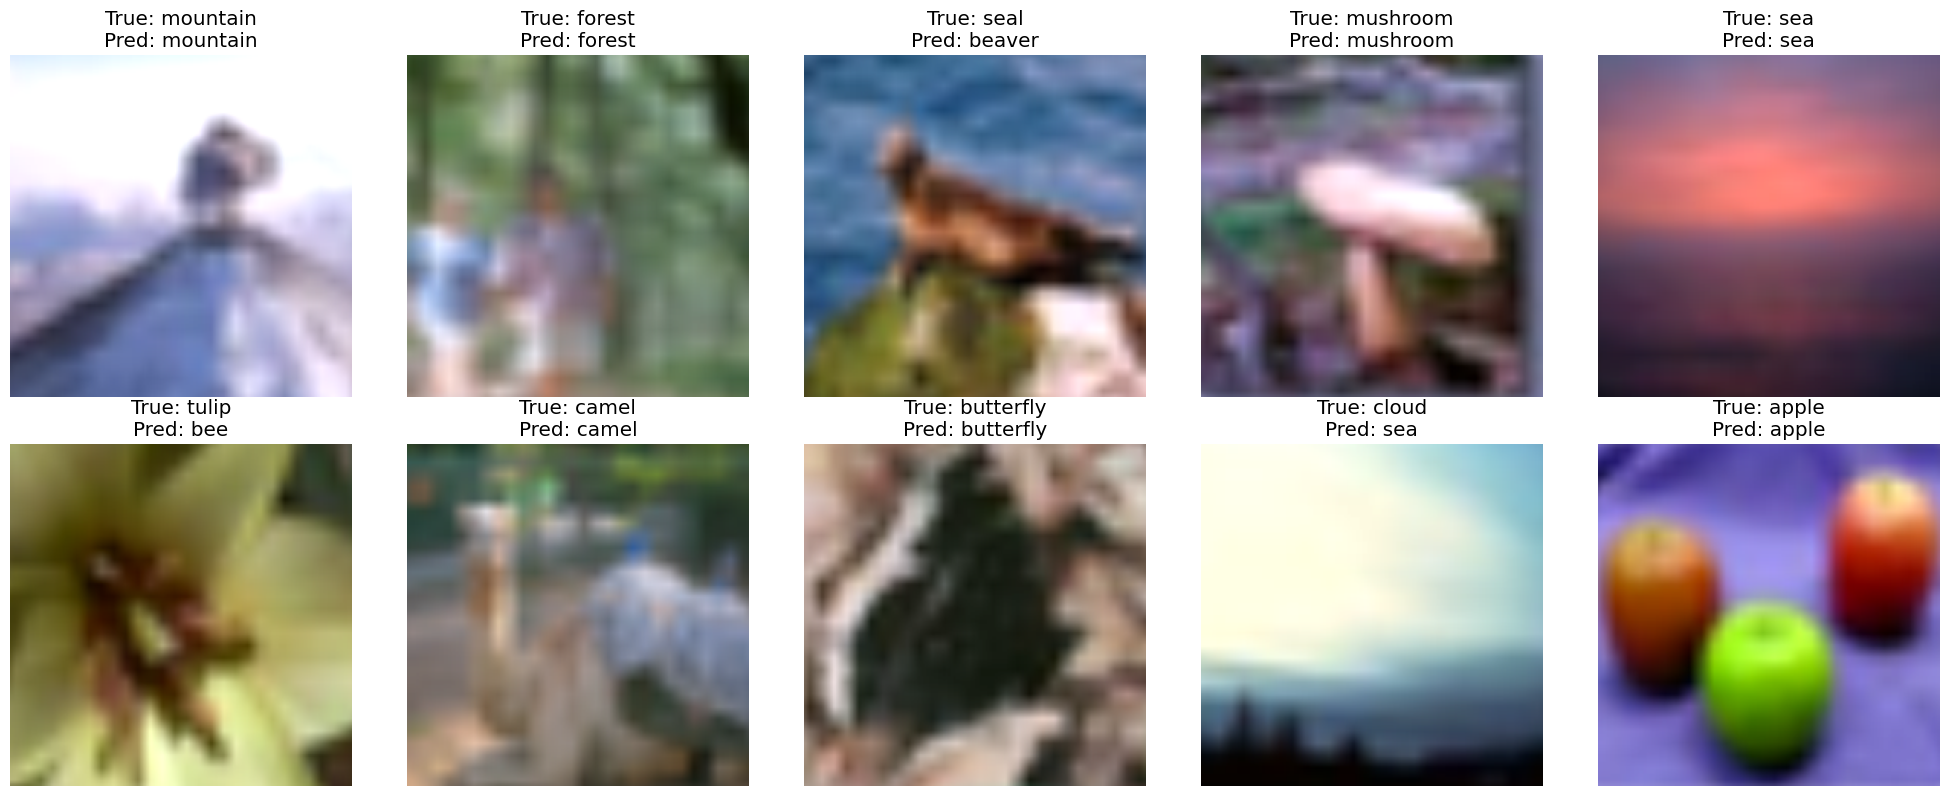

In [8]:
def show_sample_predictions(model, model_path, test_loader, class_names, num_samples=10):
    model.load_state_dict(torch.load(model_path))
    model.eval()

    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    preds = preds.cpu().numpy()

    plt.figure(figsize=(20, 8))
    for idx in range(num_samples):
        plt.subplot(2, 5, idx+1)
        img = np.transpose(images[idx], (1, 2, 0))
        img = img * np.array([0.2675, 0.2565, 0.2761]) + np.array([0.5071, 0.4867, 0.4408])
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f'True: {class_names[labels[idx]]}\nPred: {class_names[preds[idx]]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Custom CNN Sample Predictions:")
show_sample_predictions(custom_model, 'models/best_model.pth', test_loader, class_names)

print("\nResNet-18 Sample Predictions:")
show_sample_predictions(resnet18, 'models/resnet18.pth', resnet_testloader, class_names)

## 11. Conclusion
### Key Findings:
1. **Accuracy Comparison**: 
   - Custom CNN: 67.29%
   - ResNet-18: 78.21%
2. **Training Dynamics**:
* Custom CNN
   * Loss Curves: The training loss decreases steadily over the epochs, indicating that the model is learning effectively. However, the gap between training and validation loss grows larger in later epochs, suggesting some degree of overfitting.
   * Stability: You see a bit more volatility in the validation curve, especially in the early epochs. This can be attributed to the network having fewer parameters (compared to ResNet-18) and being more sensitive to initialization or learning‐rate changes.
   * Convergence: By around 20–30 epochs, the validation loss curve starts to plateau. Minor fluctuations thereafter reflect the network’s limited capacity to generalize further.

* ResNet-18
   * Loss Curves: The training loss also drops steadily, but the validation loss remains closer to the training curve than in the Custom CNN’s case—signaling better generalization.
   * Early Overfitting Check: You can see a brief phase of overfitting in the first 5–10 epochs, where training loss drops faster than validation loss. This is common for deep networks but is well‐controlled, likely thanks to techniques such as weight decay, batch normalization, and skip connections inherent to ResNet.
   * Convergence: ResNet-18 converges more quickly and ends up at a lower overall loss, aligning with the higher final accuracy.
3. **Class-wise Performance**:
* High‐Accuracy Classes: Certain classes (e.g., “apple,” “lion,” “tiger,” or others near the 80–90% mark) are likely more visually distinctive, or they match well with the features learned by the networks.

* Mid‐Range Accuracy: Some classes hover around 60–70%. These are often categories that share visual similarity with others (e.g., “bottle” vs. “bowl”) or are more variable in appearance (e.g., “cloud”).

* Lower‐Accuracy Classes: A few classes dip closer to 50%. These tend to be inherently more ambiguous (e.g., “cockroach” vs. “beetle”) or might appear infrequently in the training set, leading to poorer generalization.

The ResNet‐18 chart generally sits higher across most classes, reflecting its stronger representational capacity. The custom CNN’s class‐wise pattern is similar (higher on distinctive classes, lower on visually confusing ones), but it lags behind ResNet‐18 by ~10–15% on average.
4. **Computational Efficiency**:
* Custom CNN:
   * Single epoch takes between 25 and 50 seconds depending on training devices (both cases use CUDA)
   * Pros: Faster per‐batch training (smaller image size input), and lower memory usage.
   * Cons: The simpler architecture struggles to capture complex features, which limits peak accuracy.

* ResNet‐18:
   * Single epoch takes between 1 minute 40 seconds and 3 minutes depending on training devices (similarly both cases use CUDA)
   * Pros: Deeper architecture with residual connections helps learn more complex patterns, leading to significantly higher accuracy (78.20% vs. 66.30%).
   * Cons: More computationally expensive. Although still relatively lightweight compared to larger ResNet variants, ResNet‐18 requires more FLOPs and memory than a small custom CNN.
In practice, if you have access to a GPU and can afford the extra training time, ResNet‐18 is likely the better choice. If resources are very constrained, the custom CNN may be sufficient, though you sacrifice accuracy.
5. **Summary**:
* Accuracy: ResNet‐18 outperforms the custom CNN (78.20% vs. 66.30%).
* Generalization: ResNet‐18 shows a smaller gap between training and validation loss, indicating better generalization.
* Class‐wise: Both networks do well on highly distinctive classes and less so on ambiguous or infrequent classes. ResNet‐18’s deeper structure yields higher accuracy across the board.
* Efficiency: The custom CNN is more lightweight (smaller input size) but has a performance ceiling. ResNet‐18 requires more compute but delivers higher accuracy.

Overall, the ResNet‐18 model is the stronger performer for most applications, whereas the custom CNN may still be viable if computational resources or real‐time constraints are strict.